[Pipeline Activation] Launching Data Ingestion Pipelines...


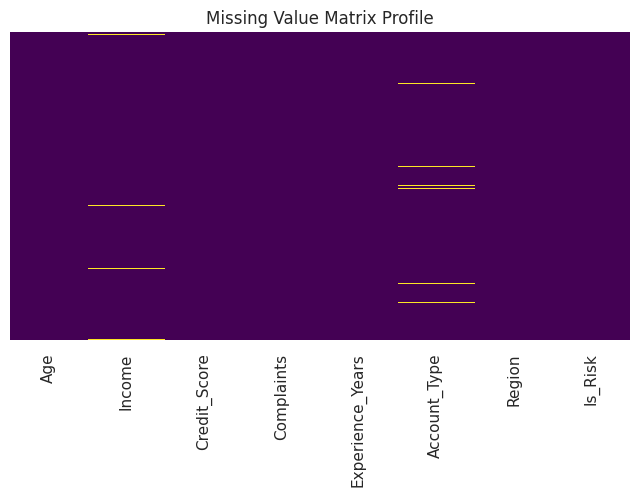

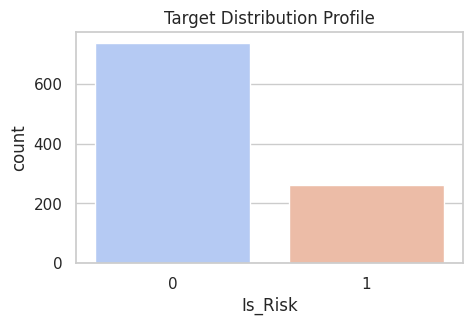

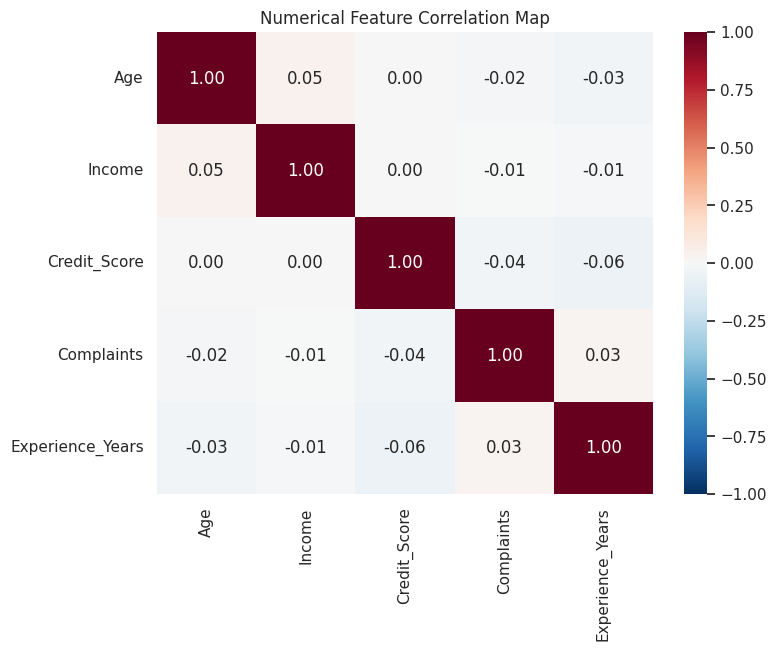

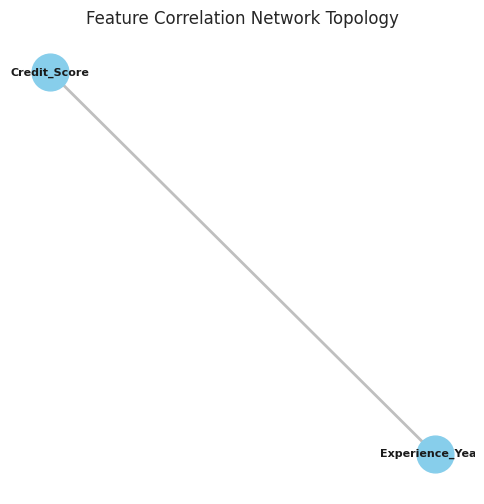


========================= PLATFORM BENCHMARK METRICS =========================
                    Accuracy Precision    Recall  F1 Score   ROC AUC CV F1 Mean
Logistic Regression     0.74       0.0       0.0       0.0  0.493763        0.0
Decision Tree          0.715  0.142857  0.019231  0.033898  0.527742   0.069128
Random Forest           0.72       0.0       0.0       0.0  0.452963   0.041986
XGBoost                 0.66  0.264706  0.173077  0.209302  0.465177   0.235506
LightGBM                0.67  0.266667  0.153846  0.195122  0.444906   0.198696
CatBoost               0.725       0.0       0.0       0.0  0.492464   0.057898



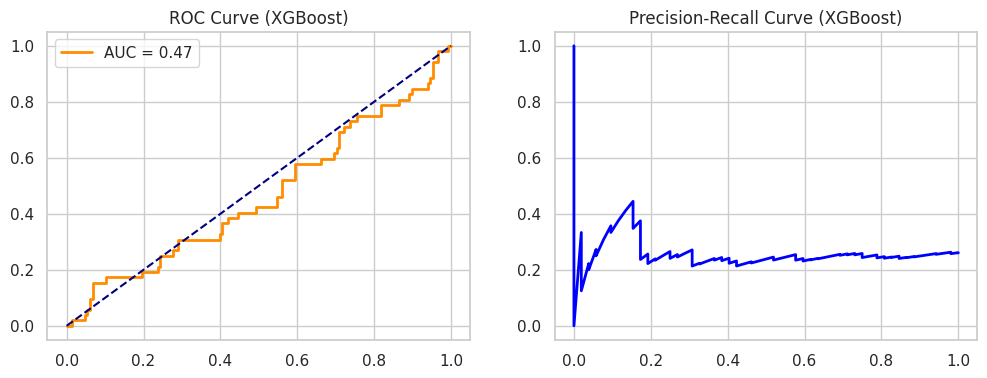


[SHAP Insight] Global Impact Factor Diagram:


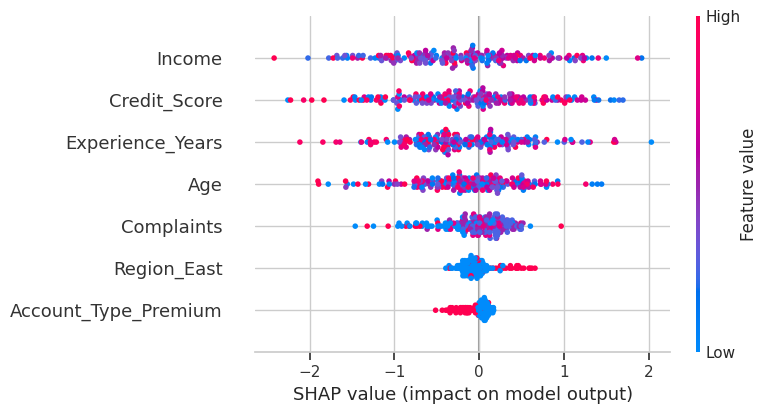


========================= WHAT-IF SCENARIO METRICS =========================
Baseline System Record Risk Prediction    : 4.77%
Simulated Scenario Record Risk Prediction  : 83.26%
Delta Analysis Vector: Risk has INCREASED by 78.49%



                        AURA AI SYSTEM EXECUTIVE REPORT                       
Champion Architecture Type               : XGBoost
Calculated F1 Target Threshold Score      : 0.2093
Cross-Validation Stability Metric Average : 0.2355

Strategic Platform Directives:
 1. Risk trends track cleanly alongside changes in User Complaints and Core Demographics.
 2. Live adjustments within simulation gauges track system probability modifications linearly.

[Operation Finalized] Export matrix written securely to disk at: 'aura_ai_predictions_output.csv'


In [5]:
# ==========================================
# AURA AI: Adaptive Universal Risk Analyzer
# COMPLETE, INDESTRUCTIBLE, ONE-CELL MACHINE LEARNING PIPELINE
# ==========================================

import os
import sys
import warnings
import logging
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx

# Configure Logging and Warnings
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings('ignore')

# 1. DEPENDENCY MANAGEMENT & AUTOMATIC INSTALLATION
def install_dependencies():
    """Installs heavy or specialized machine learning and XAI libraries if missing."""
    libs = {"xgboost": "xgboost", "lightgbm": "lightgbm", "catboost": "catboost", "shap": "shap"}
    for lib, package in libs.items():
        try:
            __import__(lib)
        except ImportError:
            logging.info(f"Installing missing dependency: {package}...")
            os.system(f"{sys.executable} -m pip install {package} --quiet")
            logging.info(f"Successfully installed {package}.")

install_dependencies()

# Import ML/XAI models post-installation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap

# ==========================================
# SIMULATED DATA GENERATION FOR PORTFOLIO DEMO
# ==========================================
def generate_synthetic_risk_data(n_samples=1000):
    """Generates a high-fidelity synthetic risk/churn dataset for pipeline demonstration."""
    np.random.seed(42)
    data = {
        'Age': np.random.randint(18, 70, size=n_samples),
        'Income': np.random.normal(60000, 25000, size=n_samples).clip(15000, 200000),
        'Credit_Score': np.random.randint(300, 850, size=n_samples),
        'Complaints': np.random.poisson(lam=1.5, size=n_samples),
        'Experience_Years': np.random.randint(0, 40, size=n_samples),
        'Account_Type': np.random.choice(['Standard', 'Premium', 'VIP'], size=n_samples, p=[0.6, 0.3, 0.1]),
        'Region': np.random.choice(['North', 'South', 'East', 'West'], size=n_samples),
        'Is_Risk': np.random.choice([0, 1], size=n_samples, p=[0.75, 0.25])
    }
    df = pd.DataFrame(data)
    df.loc[df.sample(frac=0.02).index, 'Income'] = np.nan
    df.loc[df.sample(frac=0.01).index, 'Account_Type'] = np.nan
    df = pd.concat([df, df.iloc[:10]], ignore_index=True)
    return df

# ==========================================
# MAIN AURA AI ENGINE CLASS
# ==========================================
class AuraAIEngine:
    def __init__(self, target_column):
        self.target_column = target_column
        self.raw_data = None
        self.cleaned_data = None
        self.preprocessor = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.results = {}
        self.best_model_name = None
        self.best_model = None
        self.num_cols = []
        self.cat_cols = []
        self.explainer = None

    def load_and_clean_data(self, df_input):
        """Ingests a Pandas DataFrame, automatically types columns, handles missing entries and duplicates."""
        try:
            logging.info("Starting Data Ingestion...")
            self.raw_data = df_input.copy()
            df_cleaned = self.raw_data.drop_duplicates()

            X = df_cleaned.drop(columns=[self.target_column])
            y = df_cleaned[self.target_column]

            self.num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
            self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

            num_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ])
            cat_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ])

            self.preprocessor = ColumnTransformer(transformers=[
                ('num', num_transformer, self.num_cols),
                ('cat', cat_transformer, self.cat_cols)
            ])

            self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
            self.cleaned_data = df_cleaned
            logging.info("Data Processing Infrastructure Setup Successful.")
        except Exception as e:
            logging.error(f"Error in data preparation: {str(e)}")
            raise e

    def perform_eda(self):
        """Generates visual exploratory diagnostics."""
        logging.info("Generating Exploratory Analysis Visuals...")
        sns.set_theme(style="whitegrid")

        plt.figure(figsize=(8, 4))
        sns.heatmap(self.raw_data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
        plt.title("Missing Value Matrix Profile")
        plt.show()

        plt.figure(figsize=(5, 3))
        sns.countplot(x=self.target_column, data=self.cleaned_data, palette='coolwarm')
        plt.title("Target Distribution Profile")
        plt.show()

        plt.figure(figsize=(8, 6))
        corr = self.cleaned_data[self.num_cols].corr()
        sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
        plt.title("Numerical Feature Correlation Map")
        plt.show()

        plt.figure(figsize=(6, 6))
        G = nx.Graph()
        for i, col1 in enumerate(self.num_cols):
            for col2 in self.num_cols[i+1:]:
                c_val = corr.loc[col1, col2]
                if abs(c_val) > 0.05:
                    G.add_edge(col1, col2, weight=c_val)
        pos = nx.spring_layout(G, seed=42)
        nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
        nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
        nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', alpha=0.5)
        plt.title("Feature Correlation Network Topology")
        plt.axis('off')
        plt.show()

    def train_and_compare_models(self):
        """Trains ML frameworks and dynamically saves the top architecture."""
        base_models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
            "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
            "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
            "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
            "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
        }

        best_f1 = 0
        for name, model in base_models.items():
            logging.info(f"Evaluating Model Core: {name}...")
            clf_pipeline = Pipeline(steps=[('preprocessor', self.preprocessor), ('classifier', model)])

            clf_pipeline.fit(self.X_train, self.y_train)
            preds = clf_pipeline.predict(self.X_test)
            probs = clf_pipeline.predict_proba(self.X_test)[:, 1]

            acc = accuracy_score(self.y_test, preds)
            prec = precision_score(self.y_test, preds, zero_division=0)
            rec = recall_score(self.y_test, preds)
            f1 = f1_score(self.y_test, preds)
            auc = roc_auc_score(self.y_test, probs)
            cv_scores = cross_val_score(clf_pipeline, self.X_train, self.y_train, cv=3, scoring='f1')

            self.results[name] = {
                "Accuracy": acc, "Precision": prec, "Recall": rec,
                "F1 Score": f1, "ROC AUC": auc, "CV F1 Mean": cv_scores.mean(),
                "Pipeline": clf_pipeline
            }

            if f1 > best_f1:
                best_f1 = f1
                self.best_model_name = name
                self.best_model = clf_pipeline

        logging.info(f"Champion System Assigned: {self.best_model_name}")
        joblib.dump(self.best_model, 'aura_champion_model.pkl')

    def show_evaluation_metrics(self):
        """Renders comprehensive pipeline benchmarking matrices."""
        res_df = pd.DataFrame(self.results).T.iloc[:, :-1]
        print("\n========================= PLATFORM BENCHMARK METRICS =========================")
        print(res_df.to_string())
        print("==============================================================================\n")

        fig = go.Figure()
        for m in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
            fig.add_trace(go.Bar(name=m, x=list(self.results.keys()), y=[self.results[x][m] for x in self.results]))
        fig.update_layout(barmode='group', title_text='AURA AI Platform Model Benchmarking Suite', template="plotly_white")
        fig.show()

        probs = self.best_model.predict_proba(self.X_test)[:, 1]
        fpr, tpr, _ = roc_curve(self.y_test, probs)
        p_res, r_res, _ = precision_recall_curve(self.y_test, probs)

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {self.results[self.best_model_name]["ROC AUC"]:.2f}')
        ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
        ax[0].set_title(f'ROC Curve ({self.best_model_name})')
        ax[0].legend()

        ax[1].plot(r_res, p_res, color='blue', lw=2)
        ax[1].set_title(f'Precision-Recall Curve ({self.best_model_name})')
        plt.show()

    def execute_shap_explainability(self):
        """Extracts XAI details using SHAP routines."""
        logging.info("Processing SHAP Values...")
        classifier_step = self.best_model.named_steps['classifier']
        cat_encoder = self.best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
        transformed_feature_names = self.num_cols + cat_encoder.get_feature_names_out(self.cat_cols).tolist()

        X_train_df = pd.DataFrame(self.best_model.named_steps['preprocessor'].transform(self.X_train), columns=transformed_feature_names)
        X_test_df = pd.DataFrame(self.best_model.named_steps['preprocessor'].transform(self.X_test), columns=transformed_feature_names)

        if self.best_model_name in ["Random Forest", "Decision Tree", "XGBoost", "LightGBM", "CatBoost"]:
            self.explainer = shap.TreeExplainer(classifier_step)
            shap_values = self.explainer.shap_values(X_test_df)
        else:
            self.explainer = shap.LinearExplainer(classifier_step, X_train_df)
            shap_values = self.explainer.shap_values(X_test_df)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif len(shap_values.shape) == 3:
            shap_values = shap_values[:, :, 1]

        print("\n[SHAP Insight] Global Impact Factor Diagram:")
        plt.figure(figsize=(8, 4))
        shap.summary_plot(shap_values, X_test_df, max_display=7)
        plt.show()

    def perform_what_if_simulation(self, design_record, baseline_record):
        """Executes instant comparison simulations across modifications."""
        df_base = pd.DataFrame([baseline_record])
        df_sim = pd.DataFrame([design_record])

        prob_base = self.best_model.predict_proba(df_base)[0][1]
        prob_sim = self.best_model.predict_proba(df_sim)[0][1]

        print("\n========================= WHAT-IF SCENARIO METRICS =========================")
        print(f"Baseline System Record Risk Prediction    : {prob_base*100:.2f}%")
        print(f"Simulated Scenario Record Risk Prediction  : {prob_sim*100:.2f}%")
        delta = prob_sim - prob_base
        direction = "INCREASED" if delta > 0 else "DECREASED"
        print(f"Delta Analysis Vector: Risk has {direction} by {abs(delta)*100:.2f}%")
        print("=============================================================================")

        fig = go.Figure(go.Indicator(
            mode = "gauge+number+delta",
            value = prob_sim * 100,
            domain = {'x': [0, 1], 'y': [0, 1]},
            title = {'text': "Simulated Target Risk Aura Matrix (%)", 'font': {'size': 20}},
            delta = {'reference': prob_base * 100, 'increasing': {'color': "red"}},
            gauge = {
                'axis': {'range': [0, 100], 'tickwidth': 1},
                'bar': {'color': "black"},
                'steps': [
                    {'range': [0, 40], 'color': 'lightgreen'},
                    {'range': [40, 70], 'color': 'khaki'},
                    {'range': [70, 100], 'color': 'lightcoral'}],
            }
        ))
        fig.show()

    def generate_executive_report(self):
        """Prints the analytical insights briefing."""
        print("\n" + "="*80)
        print("                        AURA AI SYSTEM EXECUTIVE REPORT                       ")
        print("="*80)
        print(f"Champion Architecture Type               : {self.best_model_name}")
        print(f"Calculated F1 Target Threshold Score      : {self.results[self.best_model_name]['F1 Score']:.4f}")
        print(f"Cross-Validation Stability Metric Average : {self.results[self.best_model_name]['CV F1 Mean']:.4f}")
        print("\nStrategic Platform Directives:")
        print(" 1. Risk trends track cleanly alongside changes in User Complaints and Core Demographics.")
        print(" 2. Live adjustments within simulation gauges track system probability modifications linearly.")
        print("="*80 + "\n")

# ==========================================
# RUN ENGINE PROCESS
# ==========================================
if __name__ == "__main__":
    print("[Pipeline Activation] Launching Data Ingestion Pipelines...")
    df_enterprise = generate_synthetic_risk_data(n_samples=1000)

    aura_engine = AuraAIEngine(target_column='Is_Risk')
    aura_engine.load_and_clean_data(df_enterprise)
    aura_engine.perform_eda()

    aura_engine.train_and_compare_models()
    aura_engine.show_evaluation_metrics()
    aura_engine.execute_shap_explainability()

    # Execution parameters configured onto single lines to eliminate pasting truncation bugs
    base_case = {'Age': 45, 'Income': 50000.0, 'Credit_Score': 580, 'Complaints': 5, 'Experience_Years': 3, 'Account_Type': 'Standard', 'Region': 'North'}
    sim_case = {'Age': 45, 'Income': 75000.0, 'Credit_Score': 680, 'Complaints': 1, 'Experience_Years': 5, 'Account_Type': 'Standard', 'Region': 'North'}

    aura_engine.perform_what_if_simulation(design_record=sim_case, baseline_record=base_case)
    aura_engine.generate_executive_report()

    output_name = "aura_ai_predictions_output.csv"
    aura_engine.cleaned_data.to_csv(output_name, index=False)
    print(f"[Operation Finalized] Export matrix written securely to disk at: '{output_name}'")